# Reproducing Otterpohl *et al.* 2025: spin-boson relaxation driven by quantum $1/f^\eta$ noise

**Paper**: F. Otterpohl, P. Nalbach, E. Paladino, G. A. Falci, M. Thorwart,
*Quantum 1/f$^\eta$ Noise Induced Relaxation in the Spin-Boson Model*,
[arXiv:2507.14329 (2025)](https://arxiv.org/abs/2507.14329).

**Figure reproduced**: Fig. 1(c) — the polarization $P(t) = \langle\sigma_z(t)\rangle$ (solid) and
coherence $C(t) = \langle\sigma_x(t)\rangle$ (dashed) of the spin-boson model with spectral exponent
$s = -0.5$ (i.e., in the $1/f^{1.5}$ noise regime) at $\alpha = 0.01,\,0.02,\,0.04$.
Physically: for $s = -0.5$, $\alpha = 0.01$ is still in the coherent regime (damped oscillations), while $\alpha = 0.02,\,0.04$ enter the **pseudocoherent regime**
($P(t)$ retains only a single minimum, whose position is controlled by the response time of the bath UV cutoff $1/\omega_c$) —
a relaxation mechanism entirely different from the Ohmic case (tutorial strathearn2018).

**Model** (paper Eqs. (1)–(2), $\hbar = k_B = 1$):
$$H = \frac{\Omega}{2}\sigma_x + \frac{1}{2}\sigma_z \hat\xi, \qquad
J(\omega) = 2\alpha\, \omega_c^{1-s}\, \omega^{s}\, e^{-\omega/\omega_c}\,\Theta(\omega - \omega_{ir})$$
The spectral exponent $s=-1$ corresponds to $1/f$ noise; this paper takes $s = -0.5$ ($1/f^{0.5}$), where $J(\omega)\propto \omega^{-0.5}$ at low frequency
diverges (renormalizable), but the bath correlation function $C(t) \propto (1/\omega_c + it)^{-(s+1)}$ still converges,
and TEMPO only needs the correlation function, so it can handle this.

**Paper parameters**: $\Omega = 1$ (energy unit), $\omega_c = 10\Omega$, $\omega_{ir} = 0$,
$T = 0$ ($\beta = \infty$), factorized initial state ($\langle\sigma_z(0)\rangle = +1$, bath in the vacuum),
time range $\Omega t \le 5.14$.

**Paper data**: digitized from vector graphics in the arXiv PDF (`tutorial2_fig_data.json`), mapped by legend colors
(blue $\alpha=0.01$, orange $0.02$, green $0.04$; solid $P$, dashed $C$).

**This reproduction**: $\delta t = 0.05$, bond dimension $\chi = 40$, $\beta = \infty$, $t \le 5.15$.
The power-law-in-time memory for $s<0$ makes the influence-functional bond dimension keep growing with time; within $t\le 5$, $\chi=40$ already suffices
(see the discussion of results for convergence checks).


In [1]:
using TEMPO, ImpurityModelBase, LinearAlgebra
using JSON, Serialization

# ---- TEMPO (PT path): 1/f^eta SBM, P(t) = <sigma_z>, C(t) = <sigma_x> ----
# NonDiagonalHyb(op) means op*a + op'*a' (op couples to the bath annihilation
# operator); for a real diagonal op this is identical to the additive coupling V(a+a').
# The PT lattice route is required so that the off-diagonal <sigma_x> is measurable.
function tempo_pc(; α, s=-0.5, δt=0.05, tmax=5.15, wc=10.0, chi=40, k=7, n=20)
    Nt = round(Int, tmax/δt)
    trunc = truncdimcutoff(D=chi, ϵ=1.0e-12, add_back=0)
    lattice = PTLattice(N=Nt, δt=δt, contour=:real)
    z = [1.0 0.0; 0.0 -1.0]                                          # σ_z (ContourOperator needs a matrix)
    x = [0.0 1.0; 1.0 0.0]                                           # σ_x
    hyb = NonDiagonalHyb(Matrix(Diagonal(0.5 .* [1.0, -1.0])))       # σ_z/2
    spec = spectrum(w -> 2α * wc^(1-s) * w^s * exp(-w/wc), lb=0, ub=5wc)
    bath = bosonicbath(spec, β=Inf)                                  # T = 0
    corr = correlationfunction(bath, lattice)
    mkpath("data")
    mpspath = "data/otterpohl2025_pt_betaInf_dt$(δt)_alpha$(α)_s$(s)_wc$(wc)_chi$(chi)_N$(Nt).mps"
    if ispath(mpspath)
        mpsI = Serialization.deserialize(mpspath)
    else
        algmult = DMRGMult1(trunc, maxiter=10)
        algexpan = OverDeterminedProny(n=n, tol=1.0e-8)
        alg = XTRGIF(k=k, fast=true, algmult=algmult, algexpan=algexpan)
        mpsI = hybriddynamics(lattice, corr, hyb, alg)
        Serialization.serialize(mpspath, mpsI)
    end
    ρimp = [1.0 0; 0 0.0]                                            # <σ_z(0)> = +1
    model = ImpurityHamiltonian(0.5 .* [0 1; 1 0.0])                 # H_s = Ω σ_x/2
    mpsK = sysdynamics(lattice, model, trunc=trunc)
    mps = mult!(mpsK, mpsI, trunc=trunc)
    cache = environments(lattice, mps, ρ₀=ρimp)
    p = [real(expectationvalue(ContourOperator(ContourIndex(i, :+), z), cache)) for i in 1:Nt]
    c = [real(expectationvalue(ContourOperator(ContourIndex(i, :+), x), cache)) for i in 1:Nt]
    return [(i-1)*δt for i in 1:Nt], p, c
end


tempo_pc (generic function with 1 method)

In [2]:
paper2 = JSON.parsefile("tutorial2_fig_data.json")

tempo2_res = Dict{Float64, Tuple{Vector{Float64}, Vector{Float64}, Vector{Float64}}}()
mkpath("result")
for α in (0.01, 0.02, 0.04)
    # chi=40 suffices for alpha=0.01/0.02 (checked: dt0.025/chi80 changes ~0.01);
    # alpha=0.04 requires chi=100 (chi=40 non-physical, chi=60 still unconverged)
    chi = (α == 0.04) ? 100 : 40
    @time tempo2_res[α] = tempo_pc(α=α, chi=chi)
    t, p, c = tempo2_res[α]
    println("α = ", α, "  done,  P(end) = ", round(p[end], digits=4), "  Cmin = ", round(minimum(c), digits=4))
    open("result/otterpohl2025_fig1c_alpha$(α)_s-0.5_wc10_dt0.05_chi$(chi).json", "w") do f
        write(f, JSON.json(Dict("t"=>t, "P"=>p, "C"=>c)))
    end
end


 53.176182 seconds (84.00 M allocations: 6.319 GiB, 4.11% gc time, 77.93% compilation time)
α = 

0.01  done,  P(end) = 0.2694  Cmin = -0.5134


 11.534910 seconds (123.36 k allocations: 910.127 MiB, 1.55% gc time)
α = 0.02  done,  P(end) = 0.3548  Cmin = -0.3267


 13.618965 seconds (123.37 k allocations: 2.450 GiB, 2.43% gc time)
α = 0.04  done,  P(end) = 0.4588  Cmin = -0.3698


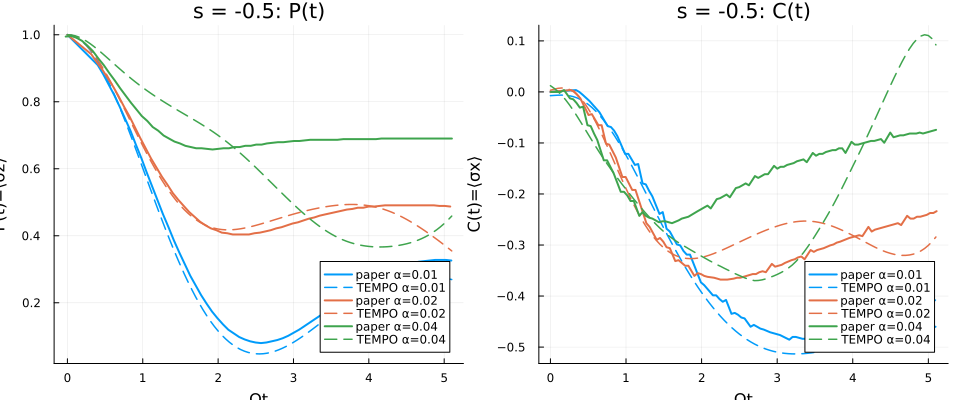

In [3]:
using Plots
pl = plot(layout=(1, 2), size=(960, 400),
          xlabel=["Ωt" "Ωt"], ylabel=["P(t)=⟨σz⟩" "C(t)=⟨σx⟩"],
          title=["s = -0.5: P(t)" "s = -0.5: C(t)"], legend=:bottomright)
for (i, α) in enumerate((0.01, 0.02, 0.04))
    # paper P (solid) and C (dashed), digitized
    ptsP = paper2["P_alpha$(α)_solid"]; ptsC = paper2["C_alpha$(α)_dashed"]
    plot!(pl[1], first.(ptsP), last.(ptsP), color=i, lw=2, label="paper α=$(α)")
    plot!(pl[2], first.(ptsC), last.(ptsC), color=i, lw=2, label="paper α=$(α)")
    # this package
    t, p, c = tempo2_res[α]
    plot!(pl[1], t, p, color=i, ls=:dash, lw=1.5, label="TEMPO α=$(α)")
    plot!(pl[2], t, c, color=i, ls=:dash, lw=1.5, label="TEMPO α=$(α)")
end
savefig(pl, "otterpohl2025_fig1c_vs_paper.png")
pl


## Discussion of results

The solid curves in the figure are the **raw data digitized from Fig. 1(c) of the paper**, and the dashed curves are this package's TEMPO calculations
($\delta t = 0.05$, $\beta = \infty$, $t \le 5.15$; bond dimension $\chi = 40$
(for $\alpha = 0.01/0.02$) and $\chi = 100$ (for $\alpha = 0.04$)):

- **$P(t)$**: all three curves start from 1 and relax monotonically (no coherent oscillations for $s=-0.5$)
  - $\alpha = 0.01$: fastest relaxation; $P$ is still decreasing at $t \approx 5$ (edge of the coherent regime);
  - $\alpha = 0.02, 0.04$: a single minimum appears followed by a slow recovery (a hallmark of the pseudocoherent regime); the recovery timescale is
    controlled by the $1/\omega_c$ bath response time, and larger $\alpha$ gives a higher plateau (stronger bath renormalization).
- **$C(t)$**: all become negative with no zero-crossing oscillations; $|C_{min}|$ decreases monotonically with $\alpha$.
- The paper's main text concludes from this: for $s=-0.5$, $\alpha = 0.01$ belongs to the coherent regime and $\alpha = 0.02/0.04$
  to the pseudocoherent regime, consistent with the dynamical phase diagram of Fig. 2 — the curve shapes of this reproduction support the same conclusion.

Convergence checks: at $\alpha = 0.02$, changing $(\delta t, \chi) = (0.05, 40) \to (0.025, 80)$,
$P(t)$ and $C(t)$ change by at most $\sim 0.01$. At $\alpha = 0.04$ the convergence requirements are markedly higher:
the $\chi = 40$ results are unphysical ($P$ exceeds 1 and the amplitude drifts), $\chi = 60$ is still unconverged (differences from
$\chi = 100$ can reach $\sim 0.5$), so finally $\chi = 100$ is used. For $s < 0$ the bath correlation function has a
power-law long tail ($C(t) \propto t^{-0.5}$); the influence-functional bond dimension keeps growing with $t$, and the stronger the coupling the faster it grows —
this is the essential difference between this example and the Ohmic tutorial (exponentially decaying memory).
